In [1]:
# ============================================================
# Cell 1: الـ Imports وربط Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ثبيت الـ random seed للـ reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# Cell 2: الـ Config — غيّر القيم هنا بس
# ============================================================
IMG_SIZE     = (96, 96)   # جرب 160 أو 224 لو الدقة وطت
BATCH_SIZE   = 32
EPOCHS_HEAD  = 10         # epochs لـ head training
EPOCHS_FT    = 10         # epochs لـ fine-tuning
FINE_TUNE_AT = 20         # فتح آخر كام layer للـ fine-tuning
DROPOUT      = 0.3

DRIVE_ROOT   = '/content/drive/MyDrive'
TRAIN_DIR    = f'{DRIVE_ROOT}/train'
VAL_DIR      = f'{DRIVE_ROOT}/valid'
TEST_DIR     = f'{DRIVE_ROOT}/test'
MODEL_PATH   = f'{DRIVE_ROOT}/drowsiness_model.keras'
HISTORY_PATH = f'{DRIVE_ROOT}/history.json'

In [4]:
# ============================================================
# Cell 3: تحميل البيانات
# ============================================================

def load_dataset(path):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        seed=SEED
    )
    ds = ds.map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

train_ds = load_dataset(TRAIN_DIR)
val_ds   = load_dataset(VAL_DIR)
test_ds  = load_dataset(TEST_DIR)

# احفظ أسماء الكلاسات قبل أي map/prefetch
raw_test    = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', seed=SEED
)
class_names = raw_test.class_names
print('Classes:', class_names)

# معاينة batch واحد
for imgs, labels in train_ds.take(1):
    print(f'Batch shape: {imgs.shape},  Labels sample: {labels[:5].numpy().flatten()}')

Found 6629 files belonging to 2 classes.
Found 1890 files belonging to 2 classes.
Found 948 files belonging to 2 classes.
Found 948 files belonging to 2 classes.
Classes: ['awake', 'drowsy']
Batch shape: (32, 96, 96, 3),  Labels sample: [1. 1. 1. 1. 0.]


In [5]:
# ============================================================
# Cell 4: بناء النموذج
# ============================================================
base = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False  # نجمد كل الـ weights في المرحلة الأولى

# Functional API أوضح من Sequential مع base model
inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base(inputs, training=False)   # training=False مهم مع BatchNorm
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(64, activation='relu')(x)
x       = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs, name='drowsiness_detector')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "drowsiness_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# ============================================================
# Cell 5: التدريب — المرحلة 1 (Head Training)
# ============================================================
print('=' * 50)
print('Phase 1: Training the classification head')
print('=' * 50)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )
]

history1 = model.fit(
    train_ds,
    epochs=EPOCHS_HEAD,
    validation_data=val_ds,
    callbacks=callbacks_phase1
)

print(f'\nBest val_accuracy (Phase 1): {max(history1.history["val_accuracy"]):.4f}')

Phase 1: Training the classification head
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 3285s 16s/step - accuracy: 0.7585 - loss: 0.4984 - val_accuracy: 0.7841 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8312 - loss: 0.3785 - val_accuracy: 0.8381 - val_loss: 0.3732 - learning_rate: 0.0010
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8507 - loss: 0.3383 - val_accuracy: 0.8471 - val_loss: 0.3460 - learning_rate: 0.0010
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8752 - loss: 0.2947 - val_accuracy: 0.8529 - val_loss: 0.3365 - learning_rate: 0.0010
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8876 - loss: 0.2739 - val_accuracy: 0.8714 - val_loss: 0.3075 - learning_rate: 0.0010
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8970 - loss: 0.2502 - val_accuracy: 0.8646 - val_loss: 0.3078 - learning_rate: 0.0010
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━

In [7]:
# ============================================================
# Cell 6: التدريب — المرحلة 2 (Fine-Tuning)
# ============================================================
print('=' * 50)
print(f'Phase 2: Fine-tuning last {FINE_TUNE_AT} layers')
print('=' * 50)

base.trainable = True

# اجمد كل حاجة غير آخر FINE_TUNE_AT layer
for layer in base.layers[:-FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count} / {len(base.layers)}')

# learning rate أصغر بكتير للـ fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    )
]

history2 = model.fit(
    train_ds,
    epochs=EPOCHS_FT,
    validation_data=val_ds,
    callbacks=callbacks_phase2
)

# حفظ الـ history كـ JSON عشان نقدر نحمله في session جديدة
with open(HISTORY_PATH, 'w') as f:
    json.dump({'h1': history1.history, 'h2': history2.history}, f)

print(f'\nBest val_accuracy (Phase 2): {max(history2.history["val_accuracy"]):.4f}')
print('Model & history saved!')

Phase 2: Fine-tuning last 20 layers
Trainable layers in base: 20 / 154
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7705 - loss: 0.6387
Epoch 1: val_accuracy improved from None to 0.90159, saving model to /content/drive/MyDrive/drowsiness_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/drowsiness_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.8024 - loss: 0.5235 - val_accuracy: 0.9016 - val_loss: 0.2633
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8669 - loss: 0.3221
Epoch 2: val_accuracy did not improve from 0.90159
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8689 - loss: 0.3061 - val_accuracy: 0.8979 - val_loss: 0.2741
Epoch 3/10
206/208 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9029 - loss: 0.2410
Epoch 3: val_accuracy did not improve from 0.90159
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9059 - loss: 0.2322 - val_accuracy: 0.8989 - val_loss: 0.2770
Epoch 4/10
203/

In [8]:
# ============================================================
# Cell 7: تقييم النموذج على الـ Test Set
# ============================================================
loss, acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy : {acc * 100:.2f}%')
print(f'Test Loss     : {loss:.4f}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 399s 13s/step - accuracy: 0.8861 - loss: 0.2785

Test Accuracy : 88.61%
Test Loss     : 0.2785


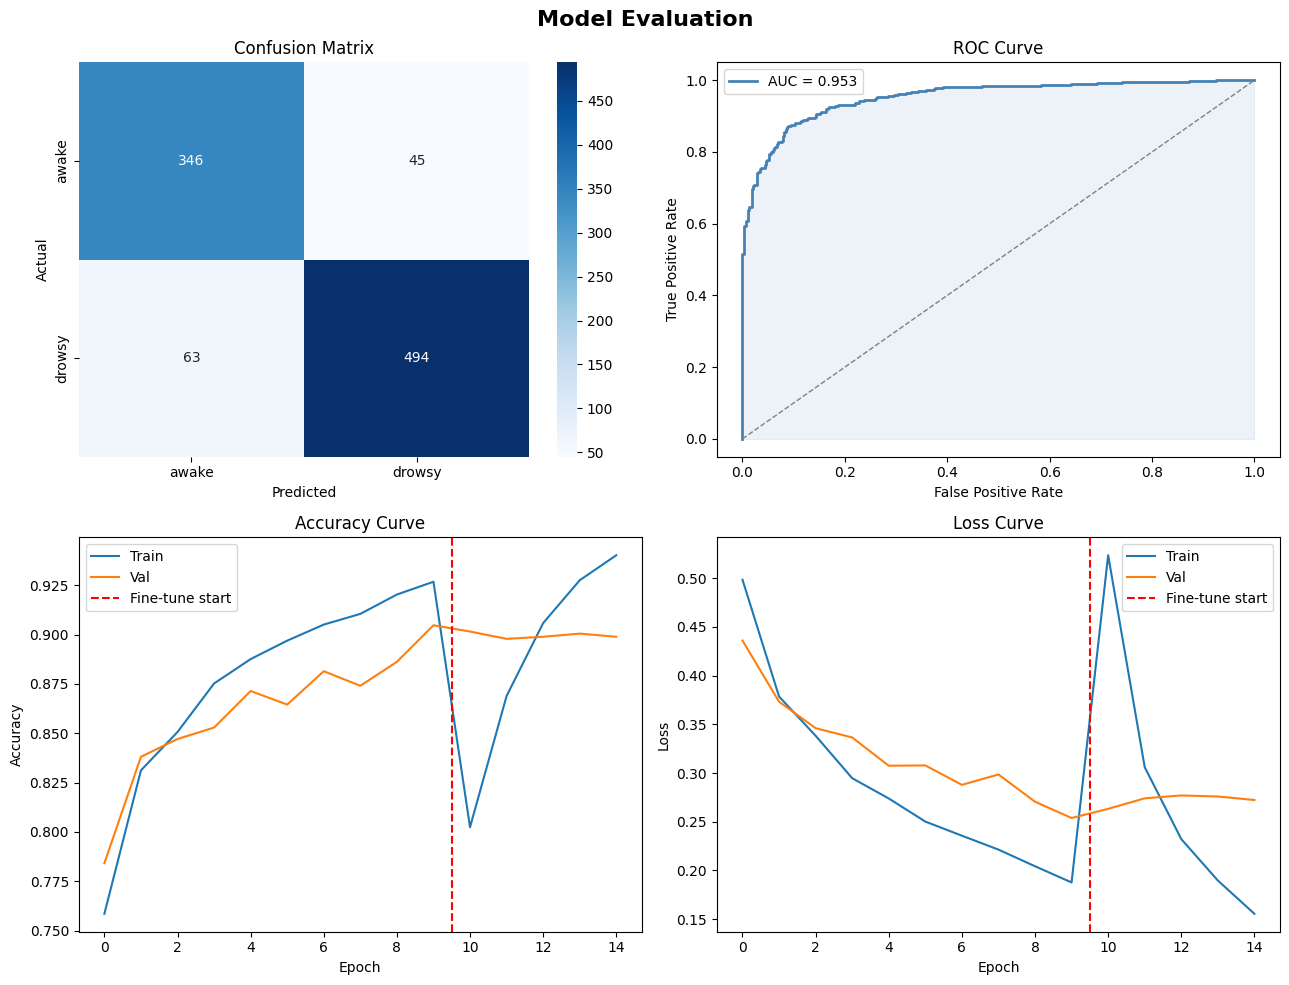


Classification Report
              precision    recall  f1-score   support

       awake       0.85      0.88      0.86       391
      drowsy       0.92      0.89      0.90       557

    accuracy                           0.89       948
   macro avg       0.88      0.89      0.88       948
weighted avg       0.89      0.89      0.89       948



In [9]:
# ============================================================
# Cell 8: الـ Evaluation الشامل
# ============================================================


# تحميل الـ history
with open(HISTORY_PATH, 'r') as f:
    h = json.load(f)
h1, h2 = h['h1'], h['h2']

# جمع predictions
y_true, y_pred_probs = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())
    y_true.extend(labels.numpy().astype(int).flatten())

y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# رسم الـ 4 charts في figure واحدة
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
ax = axes[0, 0]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# 2. ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

# 3. Accuracy Curve
ax = axes[1, 0]
split       = len(h1['accuracy'])
acc_all     = h1['accuracy']     + h2['accuracy']
val_acc_all = h1['val_accuracy'] + h2['val_accuracy']
ax.plot(acc_all,     label='Train')
ax.plot(val_acc_all, label='Val')
ax.axvline(x=split - 0.5, color='red', linestyle='--', label='Fine-tune start')
ax.set_title('Accuracy Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()

# 4. Loss Curve
ax = axes[1, 1]
loss_all     = h1['loss']     + h2['loss']
val_loss_all = h1['val_loss'] + h2['val_loss']
ax.plot(loss_all,     label='Train')
ax.plot(val_loss_all, label='Val')
ax.axvline(x=split - 0.5, color='red', linestyle='--', label='Fine-tune start')
ax.set_title('Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

plt.tight_layout()
plt.show()

# Classification Report
print('\n' + '=' * 50)
print('Classification Report')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=class_names))